In [1]:
import sys
import numpy as np
import anndata as ad

import polars as pl
import src as scit

/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
mt = ad.read_h5ad('private/data/clean_method/mutant_inferred.h5ad')

In [3]:
cttag = ad.read_h5ad('private/data/clean_method/cttag_wt_inferred.h5ad')
cttag = cttag[cttag.obs['timep']=='14_16h'].copy()

In [4]:
methylation_means = pl.read_csv('private/newest/late_methylation.csv')

rna_change = pl.read_excel('private/data/snrna_difex_MAST_per_clusters_251117_all.xlsx', sheet_id=0)
rna_change.keys()

dict_keys(['Neuronal 1', 'Epidermis', 'Muscle somatic', 'Yolk', 'Midgut', 'Fat Body', 'Tracheal', 'Glia', 'Plasmatocytes', 'Muscle visceral', 'Neuronal 2', 'Salivary Gland', 'Epidermis head', 'Sense', 'Glia lateral', 'Amnioserosa', 'Bristle'])

In [5]:
cttag_shape0 = 26324
q = 0.20#0.15658714481081903
ac_breadth = pl.read_csv('private/newest/acet_breadth.csv').filter(pl.col('breadth')>0.03*cttag_shape0)
me_breadth = pl.read_csv('private/newest/meth_breadth.csv').filter(pl.col('breadth')>0.03*cttag_shape0)

ac_broad = ac_breadth.filter(pl.col('breadth')>cttag_shape0*q)
me_broad = me_breadth.filter(pl.col('breadth')>cttag_shape0*q)
me_broad = me_broad['name'].to_numpy()
ac_broad = ac_broad['name'].to_numpy()
ac_narrow = ac_breadth.filter(pl.col('breadth')<cttag_shape0*q)
me_narrow = me_breadth.filter(pl.col('breadth')<cttag_shape0*q)
me_narrow = me_narrow['name'].to_numpy()
ac_narrow = ac_narrow['name'].to_numpy()
#me_breadth = pl.read_csv('private/data/meth_breadth.csv')
# np.savetxt('private/newest/ac_narrow.txt', ac_narrow, '%s')
# np.savetxt('private/newest/me_narrow.txt', me_narrow, '%s')
# np.savetxt('private/newest/ac_broad.txt', ac_broad, '%s')
# np.savetxt('private/newest/me_broad.txt', me_broad, '%s')

In [6]:
# active_meth = pl.read_csv('private/data/meth_active.csv', has_header=False)['column_1'].to_numpy()
#muscle_up = pl.read_csv('private/muscle_meth_up.txt', has_header=False).to_numpy().ravel()
#muscle_down = pl.read_csv('private/muscle_meth_down.txt', has_header=False).to_numpy().ravel()

In [7]:
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=False,
    #log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

In [8]:
from src.tools._layers import get_layer_feature_means
acet_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_acet)
acet_means_d = dict(zip(cttag.uns['gene_names_acet'], acet_means))
pl.DataFrame(acet_means_d).transpose(include_header=True).write_csv('private/data/acet_means_muscle.csv')

meth_means = get_layer_feature_means(cttag[cttag.obs['label'] == 'Muscle'], lc_meth)
meth_means_d = dict(zip(cttag.uns['gene_names_acet'], meth_means))
pl.DataFrame(meth_means_d).transpose(include_header=True).write_csv('private/data/meth_means_muscle.csv')

Neuronal 1


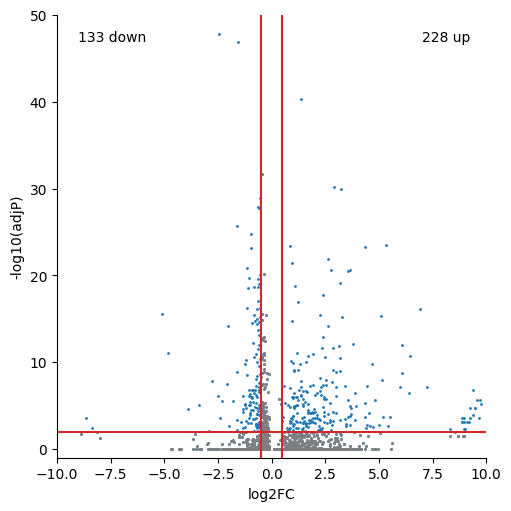

Epidermis


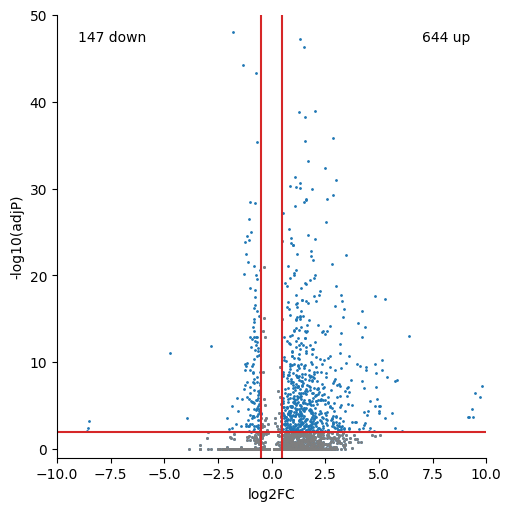

Muscle somatic


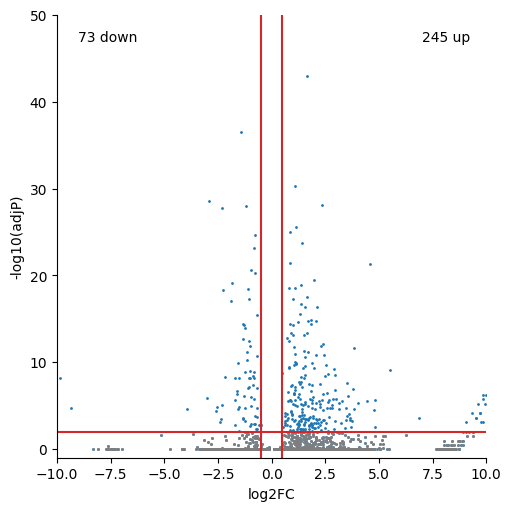

Midgut


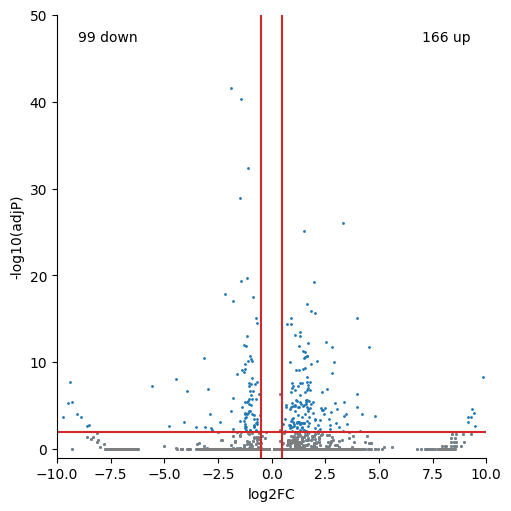

Fat Body


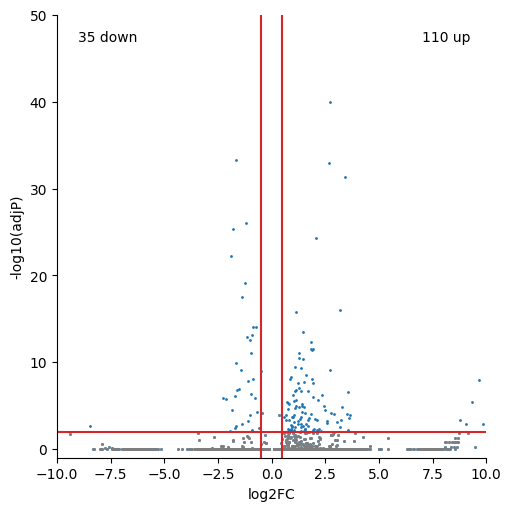

Tracheal


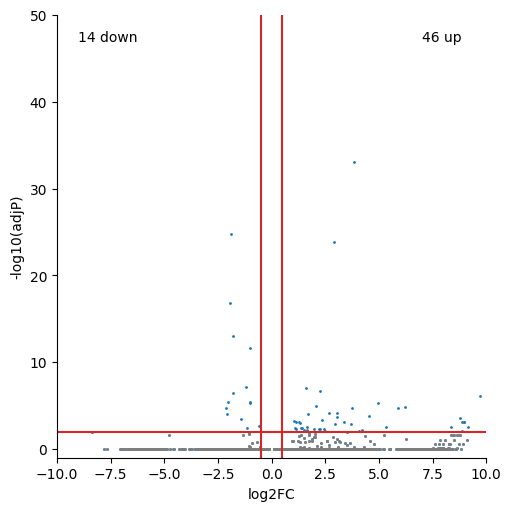

Muscle visceral


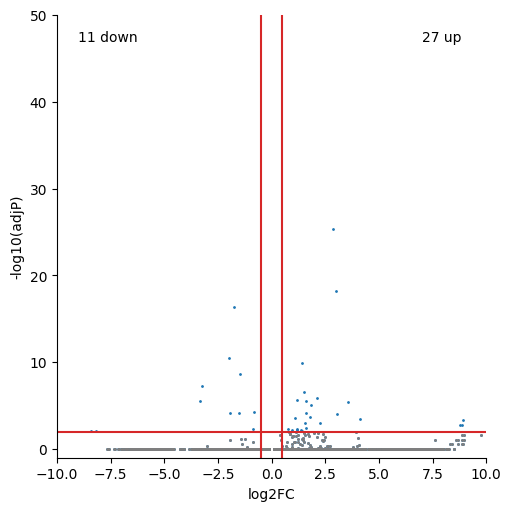

In [9]:
scit.set_defaults(figsize=(5,5))
#for k, df in rna_change.items():
for k in ['Neuronal 1', 'Epidermis', 'Muscle somatic', 'Midgut','Fat Body', 'Tracheal', 'Muscle visceral']:
    df = rna_change[k]
    print(k)
    scit.pl.volcano_plot(df['p_val_adj'].to_numpy(), df['avg_log2FC'].to_numpy(), min_pval=0.01, min_lfc=0.5, xminmax=(-10,10), yminmax=(-1, 50))

In [10]:
# df = rna_change_muscle.filter(pl.col('meth_mean').is_not_nan()).filter(pl.col('ppval') != 0)
# scit.pl.int.scatter(
#     [
#         np.c_[df['score'].to_numpy(), df['meth_mean'].to_numpy()],
#         #np.c_[df.filter(pl.col('score')<0)['ppval'].to_numpy(), df.filter(pl.col('score')<0)['meth_mean'].to_numpy()],
#     ],
#     yminmax=(-0.1,5), alpha=0.4
# 
# )


In [11]:
import polars as pl
mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('group') == 'Muscle')).with_columns(
    np.log10(pl.col('pval')).neg().alias('ppval')
)
mt_muscle_acet = pl.read_csv('private/data/wt_mt_acet_change.csv').filter((pl.col('group') == 'Muscle')).with_columns(
    np.log10(pl.col('pval')).neg().alias('ppval')
)

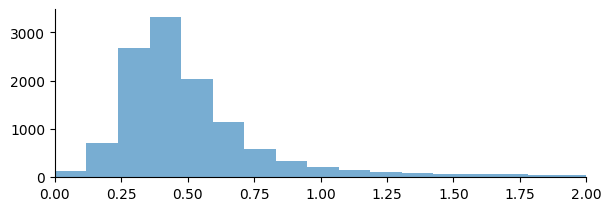

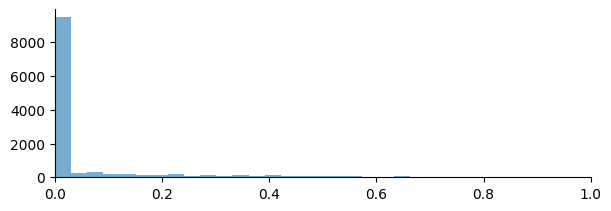

In [12]:
scit.set_defaults(figsize=(6,2))
scit.pl.int.histogram(
    [
        mt_muscle_meth['base_mean'].to_numpy(),
        #mt_muscle_acet['base_mean'].to_numpy()
    ], xminmax=(0,2), bins=200
)
scit.pl.int.histogram(
    [
        mt_muscle_meth['ppval'].to_numpy()
    ], xminmax=(0, 1), bins=200
)

In [13]:
methylated_genes = (methylation_means.filter(pl.col('Muscle') > 2))['name'].to_numpy()

mt_muscle_meth = mt_muscle_meth.filter(pl.col('name').is_in(methylated_genes))#.filter(pl.col('pval')<0.5)
mt_muscle_meth = mt_muscle_meth.with_columns(
    #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
    (pl.col('ppval') * pl.col('score')).alias('adj_score')
).sort('adj_score')
mt_muscle_meth

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.000005,-1.501535,"""RecQ5""",3.6155922,"""Muscle""",5.291242,-7.944984
9.6701e-7,-0.943194,"""mirr""",16.954054,"""Muscle""",6.01457,-5.672907
0.00001,-1.113462,"""Npc2h""",5.8908215,"""Muscle""",5.004793,-5.572645
0.000106,-1.345553,"""CG14488""",2.4963493,"""Muscle""",3.973007,-5.345891
0.00091,-1.577227,"""stumps""",1.7489872,"""Muscle""",3.04073,-4.795923
…,…,…,…,…,…,…
0.157819,0.7373233,"""AANATL2""",3.2661767,"""Muscle""",0.80184,0.591215
0.190906,0.8529994,"""Oat""",1.9735034,"""Muscle""",0.719181,0.613461
0.091038,0.594133,"""tRNA:Gly-TCC-1-3""",2.4923785,"""Muscle""",1.040778,0.618361


In [17]:
mtype = 'Muscle somatic'

muscle_up_df = rna_change[mtype].filter(pl.col('p_val') < 0.05).filter(pl.col('avg_log2FC') > 0.5)
muscle_up = muscle_up_df[['gene_name']].to_numpy().ravel()
muscle_down_df = rna_change[mtype].filter(pl.col('p_val') < 0.05).filter(pl.col('avg_log2FC') < -0.5)
muscle_down = muscle_down_df[['gene_name']].to_numpy().ravel()

In [15]:
# muscle_up_df = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval') < 0.0001).filter(pl.col('score') > 0.5)
# muscle_up = muscle_up_df[['name']].to_numpy().ravel()
# muscle_down_df = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval') < 0.0001).filter(pl.col('score') < -0.5)
# muscle_down = muscle_down_df[['name']].to_numpy().ravel()
# print(len(muscle_up))
# print(len(muscle_down))

In [18]:


def qts(df, q: list[int],tit:str, x_column: str, y_column, color='tab:red', log_transform = False):
    _m = df[x_column].to_numpy()
    qs = []
    prev = 0
    prev_dat = 0
    ls = []
    t = lambda x: x
    # if log_transform:
    #     t = lambda x: np.log1p(x)
    
    for _q in q:
        q_dat = np.quantile(_m,0.01*_q)
        v = df.filter(pl.col(x_column)<q_dat).filter(pl.col(x_column)>=prev_dat)[y_column].to_numpy()
        ls.append(f'[{prev}, {_q})')
        #ls.append(f'({prev_dat},{q_dat})')
        qs.append(t(v))
        prev_dat = q_dat
        prev = _q
    

    stat = scit.tl.statistic_test(qs, [(0,j+1) for j in range(len(qs)-1)], test_type='ttest', welch=True)
    return scit.pl.int.boxplot(
        qs,
        ls,
        xlabel=str(x_column),
        ylabel=str(y_column),
        stat=stat,
        color=color,
        title=tit,show=False,write_n=True
    )

(None,)

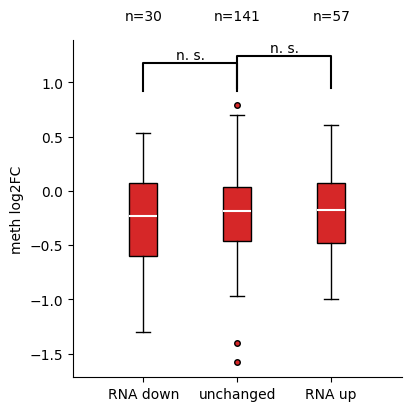

In [24]:
scit.set_defaults(figsize=(4,4))

METRIC = 'score'
# scit.pl.int.boxplot(
#     [mt_muscle_meth['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_up))['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_down))['adj_score'].to_numpy()],
#     ['all', f'RNA up \n{mtype}', f'RNA down \n {mtype}']
# ),

allgene = mt_muscle_meth[METRIC].to_numpy()
exgene = mt_muscle_meth.filter(pl.col('name').is_in(np.union1d(muscle_up, muscle_down)).not_()).filter(pl.col('name').is_in(mentioned))[METRIC].to_numpy()
upgene = mt_muscle_meth.filter(pl.col('name').is_in(muscle_up))[METRIC].to_numpy()
downgene = mt_muscle_meth.filter(pl.col('name').is_in(muscle_down))[METRIC].to_numpy()

stat = scit.tl.statistic_test([downgene,exgene,upgene],[(0,1), (2,1)],test_type='ttest',welch=True)

s = 'log2FC' if METRIC == 'score' else 'base_mean'

scit.pl.int.boxplot(
    [downgene, exgene, upgene],
    ['RNA down', 'unchanged', 'RNA up'], stat=stat,write_n=True, ylabel=f'meth {s}', color='tab:red', 
    show=False,
).savefig(f'private/newest/figures/meth_{s}_kd.pdf'),

In [54]:
exgene

array([ 3.6155922, 16.954054 ,  5.8908215,  2.4963493,  1.7489872,
        7.7566104,  3.5665402,  5.329939 ,  6.619052 ,  7.619586 ,
        5.3508496,  5.3508496,  3.9459386,  3.9459386,  2.335003 ,
       12.081108 ,  5.520312 , 10.01669  ,  6.8514996, 11.020971 ,
        2.371299 , 12.525934 ,  8.859069 ,  3.6937633,  5.2265577,
       10.875595 ,  1.739893 ,  3.3657274, 13.02916  ,  1.7694325,
        3.3926716,  1.563062 ,  5.508197 ,  2.831215 ,  3.6972113,
        9.538081 , 10.496147 , 13.014221 ,  4.6861734,  8.001579 ,
       14.104734 ,  6.075469 ,  1.560957 , 10.573477 ,  2.8657188,
        3.3403502,  4.3153176,  2.8708117,  7.9291005,  6.2414594,
        2.9273875,  1.5672808,  1.9437386,  9.946127 ,  2.9925523,
        8.412124 ,  3.9377182,  3.10432  ,  2.6925473,  2.6925473,
        5.13196  , 10.360504 , 11.087362 ,  2.984293 ,  1.9309528,
       14.37611  ,  1.96302  ,  8.120097 ,  7.621331 , 11.320068 ,
        4.0605526,  4.0605526,  7.507621 ,  4.009224 ,  7.0694

In [ ]:
scit.set_defaults(figsize=(4,4))

METRIC = 'score'
# scit.pl.int.boxplot(
#     [mt_muscle_meth['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_up))['adj_score'].to_numpy(), 
#      mt_muscle_meth.filter(pl.col('name').is_in(muscle_down))['adj_score'].to_numpy()],
#     ['all', f'RNA up \n{mtype}', f'RNA down \n {mtype}']
# ),

allgene = mt_muscle_meth[METRIC].to_numpy()
qts()

In [17]:
mt_muscle_meth

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.000005,-1.501535,"""RecQ5""",3.6155922,"""Muscle""",5.291242,-7.944984
9.6701e-7,-0.943194,"""mirr""",16.954054,"""Muscle""",6.01457,-5.672907
0.00001,-1.113462,"""Npc2h""",5.8908215,"""Muscle""",5.004793,-5.572645
0.000106,-1.345553,"""CG14488""",2.4963493,"""Muscle""",3.973007,-5.345891
0.00091,-1.577227,"""stumps""",1.7489872,"""Muscle""",3.04073,-4.795923
…,…,…,…,…,…,…
0.157819,0.7373233,"""AANATL2""",3.2661767,"""Muscle""",0.80184,0.591215
0.190906,0.8529994,"""Oat""",1.9735034,"""Muscle""",0.719181,0.613461
0.091038,0.594133,"""tRNA:Gly-TCC-1-3""",2.4923785,"""Muscle""",1.040778,0.618361


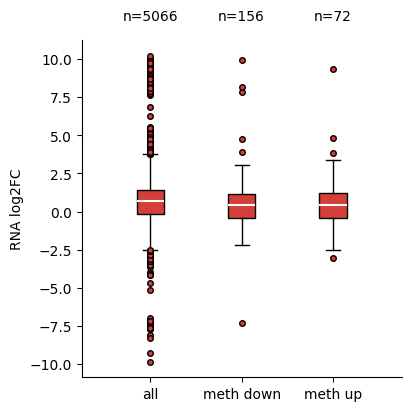

(None,)

In [22]:
scit.set_defaults(figsize=(4,4))

METRIC = 'avg_log2FC'

muscle_meth_up = mt_muscle_meth.filter(pl.col('score') > 0)['name'].to_numpy()
muscle_meth_down = mt_muscle_meth.filter(pl.col('score') < 0)['name'].to_numpy()
rna_df = rna_change[mtype]


mentioned = rna_df[['gene_name']].to_numpy().ravel()
allgene = rna_df[METRIC].to_numpy()
upgene = rna_df.filter(pl.col('gene_name').is_in(muscle_meth_up))[METRIC].to_numpy()
downgene = rna_df.filter(pl.col('gene_name').is_in(muscle_meth_down))[METRIC].to_numpy()

scit.pl.int.boxplot(
    [allgene, 
     downgene, upgene],
    ['all', f'meth down', 'meth up'], write_n=True, ylabel='RNA log2FC'
),

In [85]:
mt_muscle_meth.filter(pl.col('score') > 0)

pval,score,name,base_mean,group,ppval,adj_score
f64,f64,str,f64,str,f64,f64
0.455551,0.2566851,"""gcm2""",8.776939,"""Muscle""",0.341463,0.087648
0.4258147,0.256705,"""CG3650""",3.0471673,"""Muscle""",0.370779,0.095181
0.483216,0.3424677,"""en""",14.616566,"""Muscle""",0.315858,0.108171
0.4689634,0.358049,"""Dll""",9.658158,"""Muscle""",0.328861,0.117748
0.4835811,0.417023,"""H2.0""",4.6032357,"""Muscle""",0.315531,0.131583
…,…,…,…,…,…,…
0.157819,0.7373233,"""AANATL2""",3.2661767,"""Muscle""",0.80184,0.591215
0.190906,0.8529994,"""Oat""",1.9735034,"""Muscle""",0.719181,0.613461
0.091038,0.594133,"""tRNA:Gly-TCC-1-3""",2.4923785,"""Muscle""",1.040778,0.618361


In [99]:
meth_up = mt_muscle_meth.filter(pl.col('score') > 0.5)['name'].to_numpy()
meth_down = mt_muscle_meth.filter(pl.col('score') < -0.5)['name'].to_numpy()

In [147]:
rna_change_my = pl.read_csv('private/data/wt_mt_rna_change.csv')
rna_change_my = rna_change_my.filter(pl.col('group')=='Muscle somatic').filter(pl.col('pval')<0.05)

In [148]:
_rna = rna_change['Muscle somatic'].filter(pl.col('p_val')<0.01)

In [149]:
_rna

gene_name,p_val,avg_log2FC,pct.1,pct.2,p_val_adj
str,f64,f64,f64,f64,f64
"""lncRNA:CR34335""",3.9903e-79,2.595254,0.6,0.232,6.1023e-75
"""28SrRNA-Psi:CR45859""",5.1840e-72,-1.555866,0.701,0.934,7.9279e-68
"""lncRNA:CR40469""",1.4623e-60,2.993444,0.371,0.078,2.2362e-56
"""eEF5""",7.7753e-48,1.636447,0.538,0.217,1.1891e-43
"""28SrRNA-Psi:CR45862""",1.8706e-41,-1.421269,0.312,0.596,2.8608e-37
…,…,…,…,…,…
"""CG30196""",0.009938,1.200779,0.024,0.007,1.0
"""l(2)k01209""",0.009938,1.447095,0.024,0.007,1.0
"""CG31673""",0.009938,1.972336,0.024,0.007,1.0


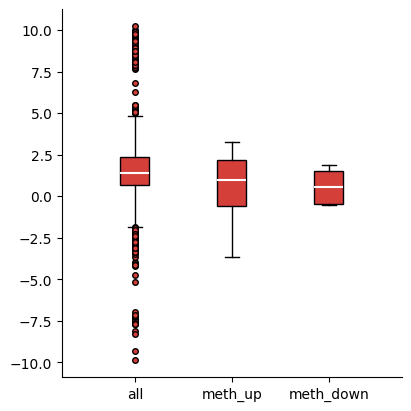

(None,)

In [151]:
scit.set_defaults(figsize=(4,4))
scit.pl.int.boxplot(
    [_rna['avg_log2FC'].to_numpy(), _rna.filter(pl.col('gene_name').is_in(meth_up))['avg_log2FC'].to_numpy(), _rna.filter(pl.col('gene_name').is_in(meth_down))['avg_log2FC'].to_numpy()],
    #[rna_change_my['score'].to_numpy(), rna_change_my.filter(pl.col('name').is_in(meth_up))['score'].to_numpy(), rna_change_my.filter(pl.col('name').is_in(meth_down))['score'].to_numpy()],
    ['all', 'meth_up', 'meth_down']
),

In [73]:
rna_change

pval,score,name,base_mean,group
f64,f64,str,f64,str
1.0,-0.055835,"""l(2)gl""",0.244264,"""Muscle somatic"""
1.0,0.0,"""CR11023""",0.0,"""Muscle somatic"""
1.0,-0.068216,"""spen""",1.533592,"""Muscle somatic"""
0.00009,0.519544,"""kis""",0.848222,"""Muscle somatic"""
0.003386,-1.159945,"""Cda5""",0.142047,"""Muscle somatic"""
…,…,…,…,…
1.0,0.0,"""lncRNA:CR45123""",0.0,"""Neuronal 2"""
1.0,0.0,"""Vml""",0.0,"""Neuronal 2"""
1.0,0.0,"""CG14422""",0.0,"""Neuronal 2"""


Muscle Muscle somatic
Meth_up: 763, Meth_down: 734


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


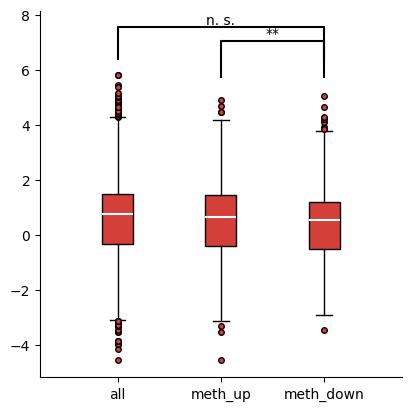

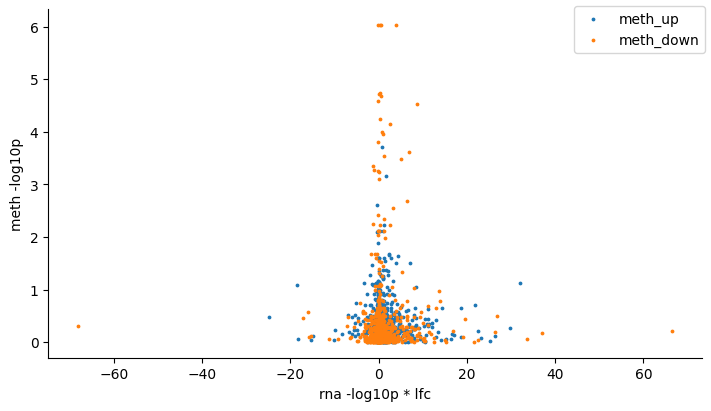

Muscle Muscle visceral
Meth_up: 618, Meth_down: 598


/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


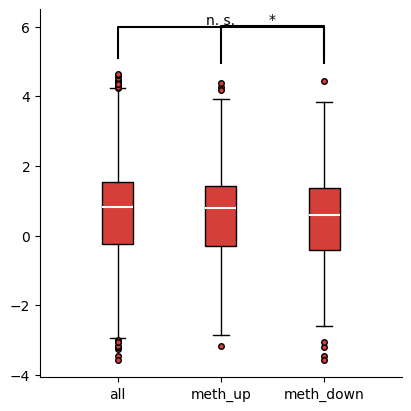

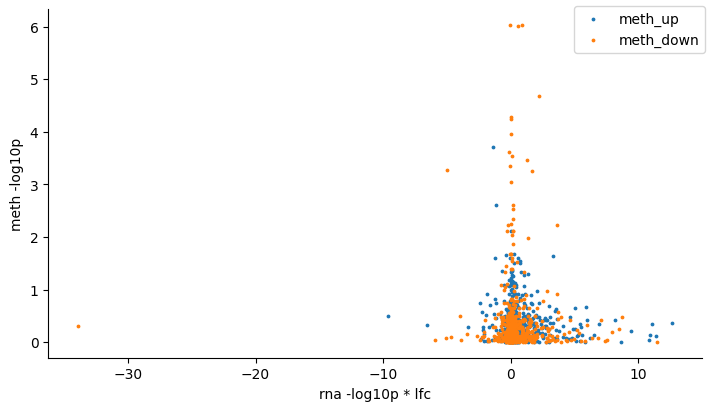

Fat Body Fat Body
Meth_up: 856, Meth_down: 912


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


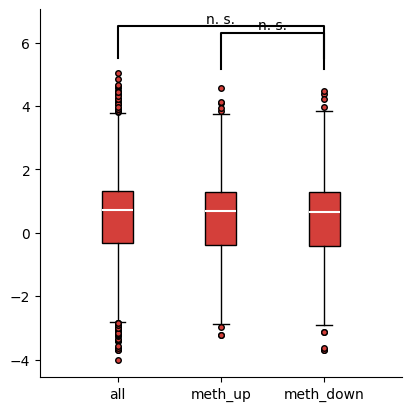

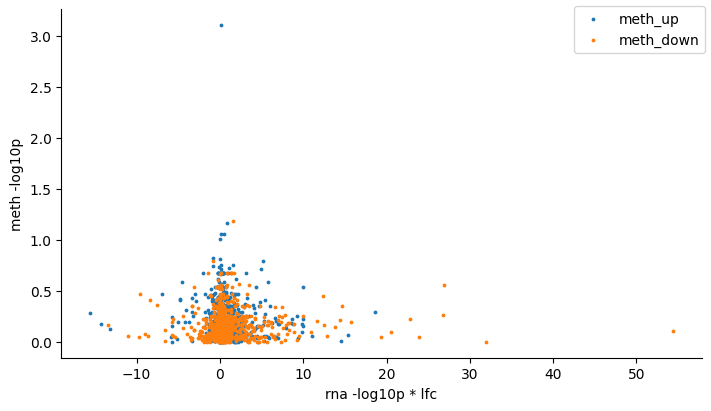

Epidermis Epidermis
Meth_up: 736, Meth_down: 816


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


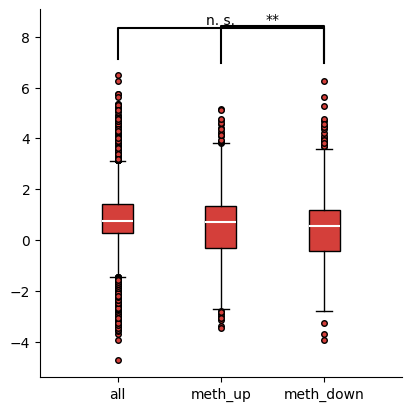

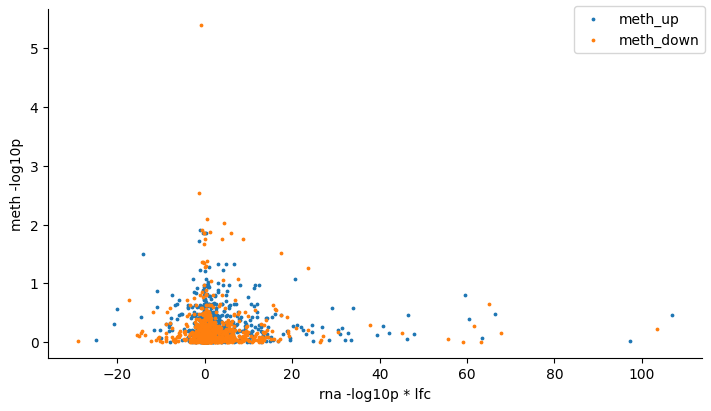

Midgut Midgut
Meth_up: 863, Meth_down: 913


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


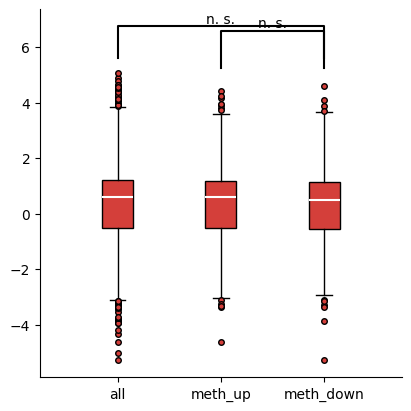

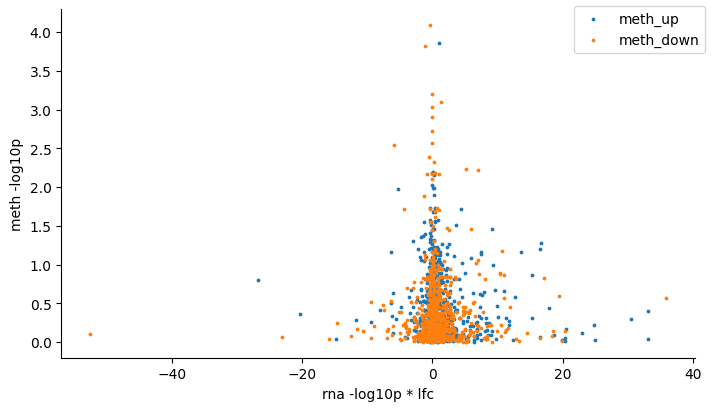

Ventral Nerve Cord Neuronal 1
Meth_up: 689, Meth_down: 703


/home/aleksander-work/Skrivbord/pyproject/venv/lib/python3.12/site-packages/polars/series/series.py:1571: RuntimeWarning: divide by zero encountered in log10
  lambda out: ufunc(*args, out=out, dtype=dtype_char, **kwargs),
/home/aleksander-work/Skrivbord/pyproject/notebooks/src/tools/_statistics.py:288: SmallSampleWarning: One or more sample arguments is too small; all returned values will be NaN. See documentation for sample size requirements.
  scores, pvals = sts.mannwhitneyu(data1, data2, **scipy_stat_kwargs)


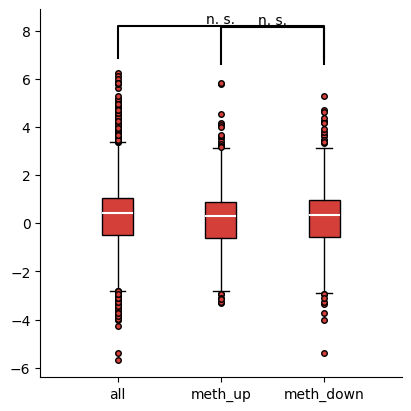

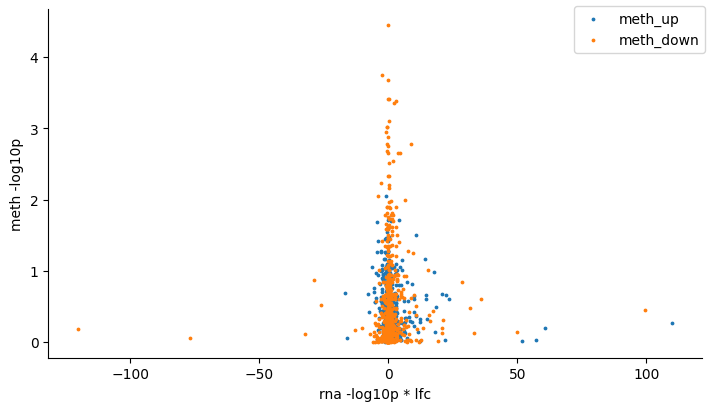

In [216]:
plots = [('Muscle', 'Muscle somatic'), ('Muscle', 'Muscle visceral'), ('Fat Body', 'Fat Body'), ('Epidermis', 'Epidermis'), ('Midgut', 'Midgut'), ('Ventral Nerve Cord', 'Neuronal 1')]
import matplotlib.pyplot as plt
RNA_PVAL_TH = 1

METH_BASE_MEAN = 0.5
METH_PVAL_TH = 1
SCORE_METH_TH = 0

for _cat in plots:
    print(_cat[0], _cat[1])
    rna_change_my = pl.read_csv('private/data/wt_mt_rna_change.csv')
    rna_change_my = rna_change_my.filter(pl.col('group')==_cat[1]).filter(pl.col('pval')<RNA_PVAL_TH)
    rna_change_my = rna_change_my.with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    ).with_columns(
        #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
        (pl.col('ppval') * pl.col('score')).alias('adj_score')
    ).sort('adj_score')

    mt_muscle_meth = pl.read_csv('private/data/wt_mt_meth_change.csv').filter((pl.col('base_mean') > METH_BASE_MEAN) & (pl.col('group') == _cat[0]))
    mt_muscle_meth = mt_muscle_meth.filter(pl.col('pval')<METH_PVAL_TH)
    mt_muscle_meth = mt_muscle_meth.with_columns(
        np.log10(pl.col('pval')).neg().alias('ppval')
    ).with_columns(
        #(pl.col('ppval') * pl.col('score').sign()).alias('adj_score')
        (pl.col('ppval') * pl.col('score')).alias('adj_score')
    ).sort('adj_score')

    joint = mt_muscle_meth.join(rna_change_my, left_on='name', right_on='name', suffix='_rna')
    
    meth_up = joint.filter(pl.col('score') > SCORE_METH_TH)['name'].to_numpy()
    meth_down = joint.filter(pl.col('score') < -SCORE_METH_TH)['name'].to_numpy()
    print(f"Meth_up: {len(meth_up)}, Meth_down: {len(meth_down)}")
    scit.set_defaults(figsize=(4,4))
    up_in = rna_change_my.filter(pl.col('name').is_in(meth_up))['score'].to_numpy()
    down_in = rna_change_my.filter(pl.col('name').is_in(meth_down))['score'].to_numpy()
    if len(up_in) == 0:
        up_in = [0]
    if len(down_in) == 0:
        down_in = [0]
    stat = None
    if len(up_in) > 1 and len(down_in) > 1:
        stat = scit.tl.statistic_test([[], up_in, down_in], [(0,2), (1,2)], test_type='mannwhitneyu')
    scit.pl.int.boxplot(
        [rna_change_my['score'].to_numpy(), up_in, down_in],
        ['all', 'meth_up', 'meth_down'], stat=stat
    )
    scit.set_defaults(figsize=(7,4))
    f=scit.pl.int.scatter(
        [
            np.c_[(joint.filter(pl.col('score')>0)['adj_score_rna']), joint.filter(pl.col('score')>0)['ppval'].to_numpy()],
            np.c_[(joint.filter(pl.col('score')<0)['adj_score_rna']), joint.filter(pl.col('score')<0)['ppval'].to_numpy()],
        ],
        ['meth_up', 'meth_down'],
        show=False
    )
    f.axes[0].set_ylabel('meth -log10p')
    f.axes[0].set_xlabel('rna -log10p * lfc')
    plt.show()

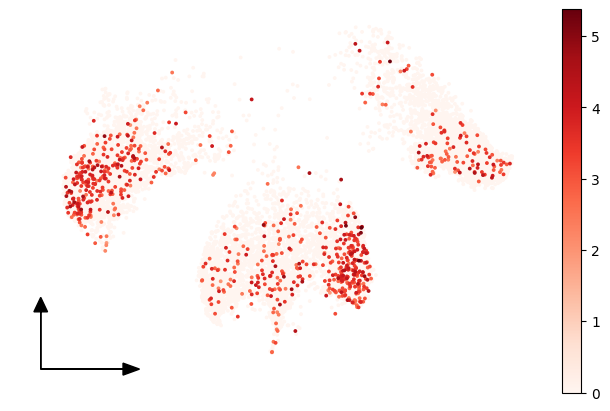

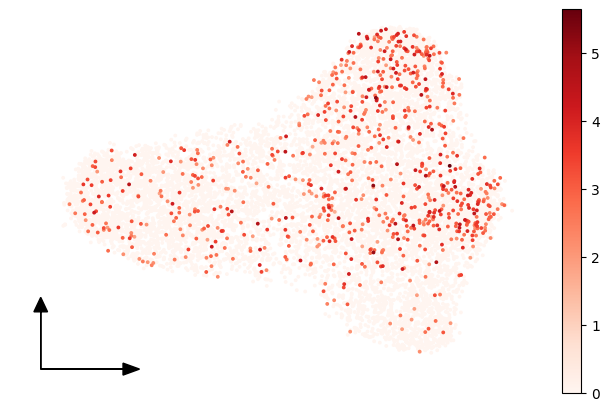

In [49]:
scit.set_defaults(figsize=(6,4))
lc_acet = scit.tl.make_layer_config(
    "acet",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)
lc_meth = scit.tl.make_layer_config(
    "meth",
    in_obsm=True,
    log_transform=True,
    normalize_with_obs_counts=True,
    feature_names=cttag.uns['gene_names_acet']
)

scit.tl.layer_pick_features(cttag, lc_meth, 'RecQ5')
scit.tl.copy_to_obs(cttag, lc_meth)
scit.pl.embedding2d(cttag, 'X_umap', 'copied_data', cmap='Reds')

scit.tl.layer_pick_features(mt, lc_meth, 'RecQ5')
scit.tl.copy_to_obs(mt, lc_meth)
scit.pl.embedding2d(mt, 'X_umap', 'copied_data', cmap='Reds')

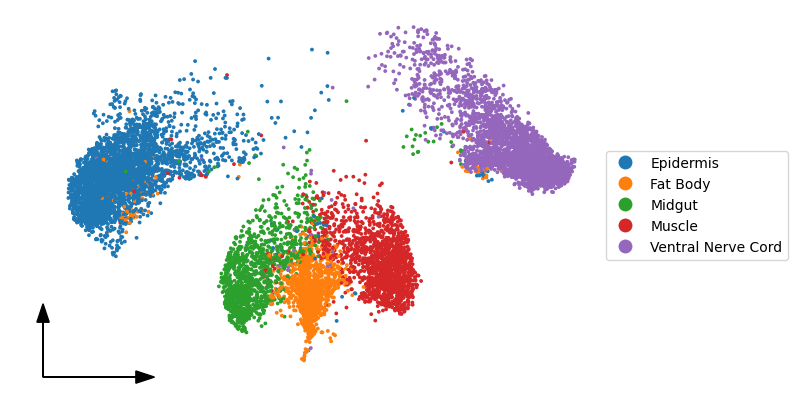

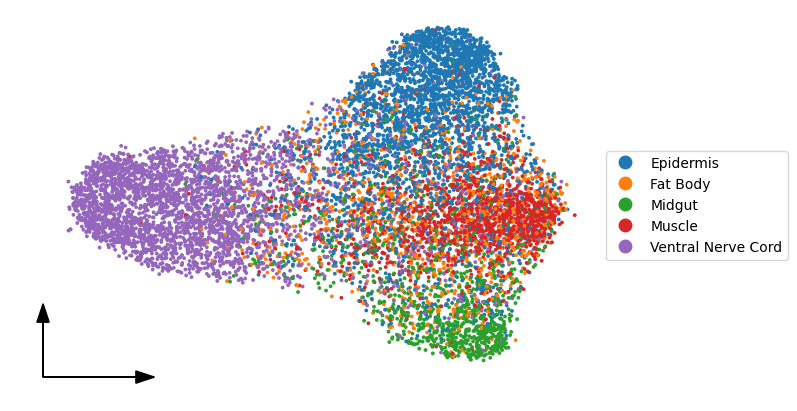

In [50]:

scit.pl.embedding2d(cttag, 'X_umap', 'label')
scit.pl.embedding2d(mt, 'X_umap', 'label')